In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\bnabla}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [3]:
rho = np.zeros((5, 100))
pdf = np.zeros((5, 100))

df = pd.read_csv(fr'data/3D/turb_PDF_rho_P0=0.1.csv', header=0)
rho[0, :] = df['rho'].tolist()
pdf[0, :] = df['pdf'].tolist() 

df = pd.read_csv(fr'data/3D/turb_PDF_rho_P0=0.5.csv', header=0)
rho[1, :] = df['rho'].tolist()
pdf[1, :] = df['pdf'].tolist() 

df = pd.read_csv(fr'data/3D/turb_PDF_rho_P0=0.9.csv', header=0)
rho[2, :] = df['rho'].tolist()
pdf[2, :] = df['pdf'].tolist() 

df = pd.read_csv(fr'data/3D/turb_PDF_rho_P0=0.99.csv', header=0)
rho[3, :] = df['rho'].tolist()
pdf[3, :] = df['pdf'].tolist() 

df = pd.read_csv(fr'data/3D/turb_PDF_rho_P0=0.999.csv', header=0)
rho[4, :] = df['rho'].tolist()
pdf[4, :] = df['pdf'].tolist() 

In [4]:
P0 = [0.5, 0.9, 0.99, 0.999]

N = 128
rho_field = np.zeros((4, N, N, N))
for i in range(4):
    rho_field[i, ...] = np.load(fr'data/3D/rho_P0={P0[i]}.npy')

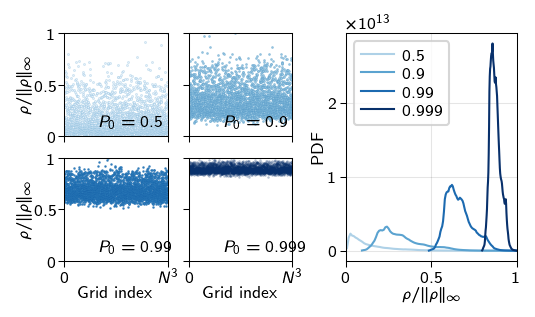

In [8]:
cmap = plt.get_cmap('Blues')
colors_face = [cmap(0.1 + 0.9*i/3) for i in range(4)]
colors_edge = [cmap(0.5 + 0.5*i/3) for i in range(4)]

fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 1.75/2.54 / fig_width
ax_height = 1.75/2.54 / fig_height

target_size = [3000, 3000, 3000, 3000]
alpha = [1, 1, 1, 0.3]

for ix in range(2):
    for iy in range(2):
        i = 2 * iy + ix
        ax = fig.add_axes([ix * (ax_width + 0.02), -iy * (ax_height + 0.02), ax_width, ax_height])

        random_indices = np.random.choice(N**3, size=target_size[i], replace=False)
        rho_plot = rho_field[i, ...].flatten()[random_indices]

        ax.scatter(np.arange(target_size[i]), rho_plot / np.amax(rho_plot), s=1, marker='o', color=colors_face[i], edgecolors=colors_edge[i], linewidths=0.1, alpha=alpha[i], rasterized=True)
        ax.text(target_size[i] / 3, 0.1, rf'$P_0={P0[i]}$')

        plt.xlim(0, target_size[i]-1) 
        plt.ylim(0, 1)
        if iy == 1:
            plt.xlabel(r'Grid index', labelpad=0, size=fontsize)
        if ix == 0:
            plt.ylabel(r'$\rho/\|\rho\|_\infty$', labelpad=1, size=fontsize) # rotation=0
        ax.set_xticks(np.linspace(0, target_size[i]-1, 2))
        ax.set_xticklabels([r'$0$', r'$N^3$'])
        ax.set_yticks(np.linspace(0, 1, 3))
        ax.set_yticklabels([r'$0$', r'$0.5$', r'$1$'])
        if iy == 0:
            ax.xaxis.set_major_formatter(NullFormatter())
        if ix == 1:
            ax.yaxis.set_major_formatter(NullFormatter())
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
        ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
        ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)


ax_height_2 = 2 * ax_height + 0.02
ax_width_2 = ax_height_2 / 4 * 3

# 
ax = fig.add_axes([2 * ax_width + 0.02 + 0.05, -(ax_height + 0.02), ax_width_2, ax_height_2])

cmap = plt.get_cmap('Blues')
labels = [r'$0.1$', r'$0.5$', r'$0.9$', r'$0.99$', r'$0.999$']

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
for i in range(1, 5):
    ax.plot(rho[i, :] / np.amax(rho[i, :]), pdf[i, :], linewidth=1, color=cmap(0.1 + 0.9*i/4), label=labels[i])

ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(0, 1), loc='upper left', fontsize=fontsize)
plt.xlim(0, 1) 
# plt.ylim(0, 1)
plt.xlabel(r'$\rho / \|\rho\|_\infty$', labelpad=0, size=fontsize)
plt.ylabel(r'PDF', labelpad=1, size=fontsize) # rotation=0
ax.set_xticks(np.linspace(0, 1, 3))
ax.set_xticklabels([r'$0$', r'$0.5$', r'$1$'])
ax.set_yticks(np.linspace(0, 2e13, 3))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)

# 
plt.savefig(fr'figures/rho_pdf.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight', dpi=600)